# EDA 03 (Bureau Balance)

## Resumen


In [1]:
import sys
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, norm, spearmanr, pearsonr, chi2_contingency
from scipy.stats.contingency import association

sys.path.insert(0, str(Path.cwd().parent))
from src.data.loader import load_table, verify_dtypes
from src.features.eval import EvaluadorSenal

COLOR_NODEF, COLOR_DEF = "steelblue", "crimson"

### 1. Carga

In [2]:
bb = load_table("bureau_balance")
bureau = load_table("bureau")
train = load_table("application_train")

bb.info(memory_usage="deep")
bb.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype   
---  ------          -----   
 0   SK_ID_BUREAU    uint32  
 1   MONTHS_BALANCE  int8    
 2   STATUS          category
dtypes: category(1), int8(1), uint32(1)
memory usage: 156.2 MB


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [3]:
# la unicidad del par (SK_ID_BUREAU, MONTHS_BALANCE) implica la unicidad de la fila completa
n_dup_row = int(bb.duplicated().sum())
assert not bb.duplicated(subset=["SK_ID_BUREAU", "MONTHS_BALANCE"]).any(), "par crédito-mes no único"
print(f"filas: {len(bb):,} | SK_ID_BUREAU únicos: {bb['SK_ID_BUREAU'].nunique():,}")
print(f"Integridad: par (SK_ID_BUREAU, MONTHS_BALANCE) único | duplicados de fila completa: {n_dup_row}")
print(f"nulos literales por columna: {bb.isnull().sum().to_dict()}")  # 0 en las 3: la ausencia es STATUS='X'

filas: 27,299,925 | SK_ID_BUREAU únicos: 817,395
Integridad: par (SK_ID_BUREAU, MONTHS_BALANCE) único | duplicados de fila completa: 0
nulos literales por columna: {'SK_ID_BUREAU': 0, 'MONTHS_BALANCE': 0, 'STATUS': 0}


In [4]:
# cobertura triple: bureau_balance - bureau - train (SK_ID_BUREAU es PK en bureau)
bb_ids = bb["SK_ID_BUREAU"].unique()
en_bureau = bureau["SK_ID_BUREAU"].isin(bb_ids)            # créditos de bureau que tienen histórico
bureau_train = bureau[bureau["SK_ID_CURR"].isin(train["SK_ID_CURR"])]
map_bc = bureau_train.loc[bureau_train["SK_ID_BUREAU"].isin(bb_ids), ["SK_ID_BUREAU", "SK_ID_CURR"]]

n_cred, n_train = len(bb_ids), train["SK_ID_CURR"].nunique()
cli_bureau, cli_hist = bureau_train["SK_ID_CURR"].nunique(), map_bc["SK_ID_CURR"].nunique()

print(f"créditos con histórico: {n_cred:,} | en bureau: {en_bureau.sum():,} | huérfanos: {n_cred - en_bureau.sum():,}")
print(f"créditos de bureau con histórico mensual: {en_bureau.mean() * 100:.2f}%")
print(f"clientes con historial bureau: {cli_bureau:,} ({cli_bureau / n_train * 100:.2f}%)")
print(f"clientes con histórico mensual: {cli_hist:,} ({cli_hist / n_train * 100:.2f}%)")

créditos con histórico: 817,395 | en bureau: 774,354 | huérfanos: 43,041
créditos de bureau con histórico mensual: 45.11%
clientes con historial bureau: 263,491 (85.69%)
clientes con histórico mensual: 92,231 (29.99%)


In [5]:
# ¿la cobertura es del crédito o del cliente? de eso depende que una flag de mora agregada sea interpretable
tiene = bureau_train["SK_ID_BUREAU"].isin(bb_ids)
cob = tiene.groupby(bureau_train["SK_ID_CURR"]).agg(total="size", con="sum")
con_bal = cob[cob["con"] > 0]
completa = con_bal["con"].eq(con_bal["total"])
tgt_cli = train.set_index("SK_ID_CURR")["TARGET"]
print(f"clientes con algún histórico mensual: {len(con_bal):,} | con todos sus créditos cubiertos: "
      f"{int(completa.sum()):,} ({completa.mean() * 100:.2f}%) | con cobertura parcial: {int((~completa).sum())}")
print(f"default con cobertura completa: {tgt_cli.reindex(con_bal.index[completa]).mean() * 100:.2f}%")

# ¿y depende de algún atributo del crédito? (grupos con menos de 5.000 créditos quedan fuera por muestra)
antig = pd.cut(-bureau_train["DAYS_CREDIT"] / 365.25, [0, 1, 3, 5, 50], labels=["0-1a", "1-3a", "3-5a", "5a+"])
filas = []
for eje, clave in [("CREDIT_ACTIVE", bureau_train["CREDIT_ACTIVE"].astype(str)),
                   ("CREDIT_TYPE", bureau_train["CREDIT_TYPE"].astype(str)),
                   ("antigüedad", antig)]:
    t = tiene.groupby(clave, observed=True).agg(n="size", pct="mean")
    for grupo, r in t[t["n"] >= 5000].iterrows():
        filas.append({"eje": eje, "grupo": grupo, "créditos": int(r["n"]), "% con histórico": round(r["pct"] * 100, 2)})
display(pd.DataFrame(filas))

clientes con algún histórico mensual: 92,231 | con todos sus créditos cubiertos: 92,028 (99.78%) | con cobertura parcial: 203
default con cobertura completa: 8.11%


,eje,grupo,créditos,% con histórico
0,CREDIT_ACTIVE,Active,541919,35.68
1,CREDIT_ACTIVE,Closed,917733,35.75
2,CREDIT_ACTIVE,Sold,5653,36.39
3,CREDIT_TYPE,Car loan,23757,36.08
4,CREDIT_TYPE,Consumer credit,1069610,35.68
5,CREDIT_TYPE,Credit card,343853,35.42
6,CREDIT_TYPE,Microloan,9005,49.51
7,CREDIT_TYPE,Mortgage,15607,37.18
8,antigüedad,0-1a,279128,36.79
9,antigüedad,1-3a,521761,36.22


La tabla tiene 27.299.925 filas y 3 columnas (156,2 MB tras `reduce_mem_usage`), sin un solo
duplicado de fila ni del par `(SK_ID_BUREAU, MONTHS_BALANCE)`, cada fila es un crédito mes único,
como esperaba. Hay 817.395 créditos con histórico mensual.

La cobertura es lo primero que me impacta y tiene consecuencias. Solo el **45,11%** de los créditos de `bureau` tiene histórico mensual, y **43.041 `SK_ID_BUREAU`** del balance no existen en `bureau`: son huérfanos que se pierden al cruzar con el `TARGET` (sin `bureau` no hay `SK_ID_CURR`).

A nivel cliente: de los 263.491 clientes de train con historial en `bureau` (85,69%), solo **92.231 (29,99%) tienen histórico mensual**. Es un tercio del dataset, muy por debajo de la cobertura de
`bureau`.

Antes de seguir necesitaba saber de qué tipo es esa cobertura, porque un 45,11% de créditos cubiertos admite dos
lecturas muy distintas: que de cada cliente vea unos créditos sí y otros no, o que el buró reporte o no reporte el
historial completo del cliente. La diferencia no es menor, porque en el primer caso cualquier medida de mora agregada
sería ambigua, ya que un cliente sin mora podría tenerla en los créditos que no veo.

Es lo segundo, y de forma casi absoluta: de los 92.231 clientes con histórico mensual, 92.028 (99,78%) lo tienen para
todos sus créditos de bureau, y solo 203 tienen cobertura parcial. Y la cobertura tampoco depende de cómo sea el
crédito: 35,68% en los activos, 35,75% en los cerrados y 36,39% en los vendidos, entre 35,42% y 37,18% por tipo de
producto (con Microloan como única excepción, 49,51% sobre 9.005 créditos), y 36,79% en el primer año frente a 32,42%
a más de cinco. La cobertura es una propiedad del cliente, no del crédito ni del producto.

Esto me anticipa que `HAS_BUREAU_BALANCE` medirá disponibilidad de reporte del buró, pero no necesariamente riesgo, y
me deja el terreno limpio para la agregación: cuando mida mora a nivel cliente estaré viendo su historial entero o no
estaré viendo nada, sin medias tintas que confundan ausencia de mora con ausencia de crédito observado.

### 2. Distribución variable objetivo (`BB_MONTHS_COUNT`) + cruce con `TARGET`

count    817395.00
mean         33.40
std          25.79
min           1.00
50%          26.00
75%          48.00
90%          77.00
95%          90.00
99%          97.00
max          97.00
dtype: float64


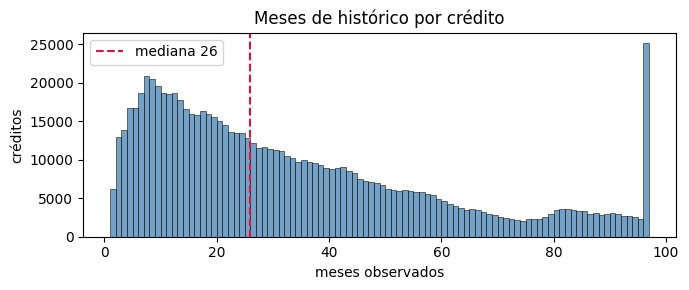

In [6]:
# BB_MONTHS_COUNT: meses de histórico observados por crédito
meses_credito = bb.groupby("SK_ID_BUREAU").size()
print(meses_credito.describe(percentiles=[.5, .75, .9, .95, .99]).round(2))

fig, ax = plt.subplots(figsize=(7, 3))
sns.histplot(meses_credito, binwidth=1, color=COLOR_NODEF, ax=ax)
ax.axvline(meses_credito.median(), color=COLOR_DEF, ls="--", label=f"mediana {meses_credito.median():.0f}")
ax.set(title="Meses de histórico por crédito", xlabel="meses observados", ylabel="créditos")
ax.legend(); plt.tight_layout(); plt.show()

                    n   tasa
sin histórico  215280   8.04
1-12m           11866  11.85
13-24m          14911  10.20
25-48m          27573   7.91
49m+            37881   6.34


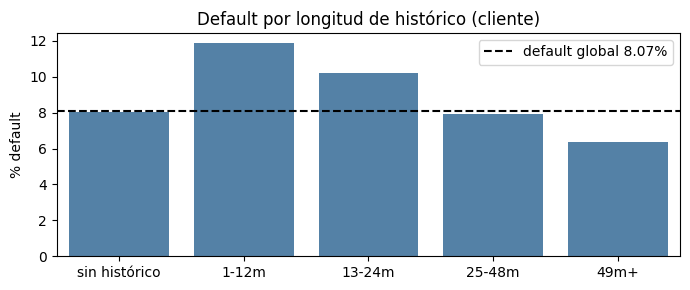

In [7]:
# histórico máximo por cliente (BB_MONTHS_MAX); 0 = cliente sin histórico mensual
mc = meses_credito.rename("meses").reset_index().merge(map_bc, on="SK_ID_BUREAU")
bb_months_max = mc.groupby("SK_ID_CURR")["meses"].max().reindex(train["SK_ID_CURR"], fill_value=0).values
target = train["TARGET"].values

bins, labels = [-1, 0, 12, 24, 48, np.inf], ["sin histórico", "1-12m", "13-24m", "25-48m", "49m+"]
binned = pd.cut(bb_months_max, bins=bins, labels=labels)
tab = pd.Series(target).groupby(binned, observed=False).agg(n="size", tasa="mean")
tab["tasa"] = (tab["tasa"] * 100).round(2)
print(tab)

fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(x=tab.index, y=tab["tasa"], color=COLOR_NODEF, ax=ax)
ax.axhline(target.mean() * 100, color="black", ls="--", label=f"default global {target.mean()*100:.2f}%")
ax.set(title="Default por longitud de histórico (cliente)", xlabel="", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [8]:
# effect size de la longitud de histórico (solo clientes con histórico)
has = bb_months_max > 0
x0, x1 = bb_months_max[has & (target == 0)], bb_months_max[has & (target == 1)]
u, p_mw = mannwhitneyu(x0, x1)
r_rb = abs(2 * u / (len(x0) * len(x1)) - 1)
rho, _ = spearmanr(bb_months_max[has], target[has])
r, _ = pearsonr(bb_months_max[has], target[has])
print(f"BB_MONTHS_MAX (con histórico): rank-biserial={r_rb:.4f} (p={p_mw:.1e}) | Pearson={r:.4f} | Spearman={rho:.4f}")

# presencia: con histórico vs sin histórico (z-test de proporciones + IC 95%)
p1, n1 = target[has].mean(), int(has.sum())
p0, n0 = target[~has].mean(), int((~has).sum())
pp = target.mean()
z = (p1 - p0) / np.sqrt(pp * (1 - pp) * (1 / n1 + 1 / n0))
margin = 1.96 * np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
print(f"con histórico {p1*100:.2f}% (n={n1:,}) vs sin histórico {p0*100:.2f}% (n={n0:,}) | "
      f"delta {(p1-p0)*100:+.2f}pp | z={z:.2f} p={2*norm.sf(abs(z)):.3f} | "
      f"IC95 [{(p1-p0-margin)*100:+.2f}, {(p1-p0+margin)*100:+.2f}]pp")

BB_MONTHS_MAX (con histórico): rank-biserial=0.1502 (p=1.7e-103) | Pearson=-0.0688 | Spearman=-0.0711
con histórico 8.14% (n=92,231) vs sin histórico 8.04% (n=215,280) | delta +0.10pp | z=0.93 p=0.353 | IC95 [-0.11, +0.31]pp


La longitud del histórico mensual por crédito es asimétrica con cola larga: mediana 26 meses, media 33,4, y una acumulación en el tope de 97 meses (unos 8 años, créditos seguidos desde el inicio de la ventana del buró).

La hipótesis que planteé era doble: más meses de histórico implicaría cliente más establecido lo que conllevaba menor riesgo, y quizá la simple presencia de histórico ya discriminaba.

Entre los clientes con histórico, el gradiente de default es monótono decreciente y limpio: 1-12 meses 11,85%, 13-24 10,20%, 25-48 7,91%, 49+ 6,34% (un factor de 1,9 del extremo corto al largo). Pero la relación no es globalmente monótona: el grupo sin histórico (8,04%, n=215.280) cae en medio, pegado a la base, no en un extremo. El riesgo lo concentran los históricos **cortos**, no la ausencia de histórico.

Lo confirma el z-test de presencia: con histórico 8,14% vs sin histórico 8,04%, un delta de +0,10pp (z=0,93, p=0,353, IC95 [-0,11, +0,31]pp) que no es significativo. Al contrario que en `bureau`, donde no tener historial sí marcaba -2,39pp, aquí la disponibilidad del histórico la decide el buró que reporta, no el riesgo del cliente. Consecuencia: `HAS_BUREAU_BALANCE` será una flag de control cuando agregue a nivel cliente, no un predictor.

El effect size lo remata con un matiz de forma: rank-biserial 0,1502 (moderado) frente a Pearson -0,069 y Spearman -0,071 (bajos). La brecha entre rank-biserial y Pearson indica una relación monótona no lineal, con efecto umbral en los históricos cortos, así que al construir las features conviene binning o transformación, no el valor continuo directo.

Queda una sospecha. La longitud del histórico mensual mide profundidad de historial crediticio, que es exactamente lo que mide `BUREAU_DAYS_CREDIT_MIN` en `bureau` (la antigüedad del crédito más antiguo), así que es muy probable que sean redundantes. No la descarto aquí: la redundancia se comprueba con las dos ya agregadas a nivel cliente.

### 3. Verificación dtypes / Clasificación variables

In [9]:
display(verify_dtypes("bureau_balance", bb))
# STATUS es la única variable analítica: ordinal 0-5 (DPD) con C (cerrado) y X (sin dato) fuera de escala
print("SK_ID_BUREAU: identificador | MONTHS_BALANCE: temporal int8 [-96, 0] | STATUS: categórica ordinal (0-5) + C/X fuera de escala")

,Variable,Tipo Actual,Categoría Esperada,Estado,Detalle
0,SK_ID_BUREAU,uint32,ID,OK,
1,MONTHS_BALANCE,int8,Days/Time,OK,
2,STATUS,category,Categorical,OK,


SK_ID_BUREAU: identificador | MONTHS_BALANCE: temporal int8 [-96, 0] | STATUS: categórica ordinal (0-5) + C/X fuera de escala


Los tres dtypes salen OK: `SK_ID_BUREAU` uint32 (identificador), `MONTHS_BALANCE` int8 (temporal, rango [-96, 0]) y `STATUS` category. Ya son óptimos tras `reduce_mem_usage`; no hay nada que recodificar por tipo.

Lo único a retener: `STATUS` es la única variable analítica y no es una categórica plana, sino ordinal (0-5 = tramos de DPD) con `C` (cerrado) y `X` (sin dato) fuera de escala.

### 4. Análisis distribuciones variables

In [10]:
vc = bb["STATUS"].value_counts()
dist = pd.DataFrame({"n": vc, "%": (vc / len(bb) * 100).round(3)})
display(dist)
dpd = vc[["1", "2", "3", "4", "5"]].sum()
print(f"DPD real (1-5): {dpd:,} ({dpd / len(bb) * 100:.2f}%)")
s = bb["STATUS"].astype("string")
print(f"higiene STATUS: {s.nunique()} niveles vs {s.str.strip().str.upper().nunique()} normalizados")

,n,%
STATUS,,
C,13646993,49.989
0,7499507,27.471
X,5810482,21.284
1,242347,0.888
5,62406,0.229
2,23419,0.086
3,8924,0.033
4,5847,0.021


DPD real (1-5): 342,943 (1.26%)


higiene STATUS: 8 niveles vs 8 normalizados


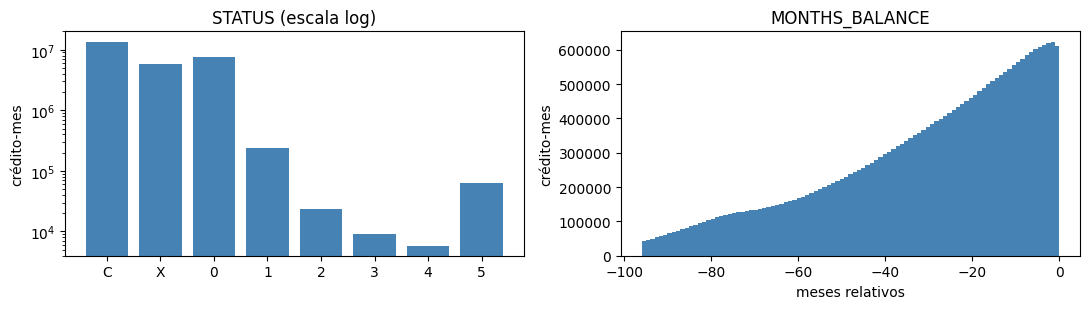

MONTHS_BALANCE: rango [-96, 0], mediana -25


In [11]:
orden = ["C", "X", "0", "1", "2", "3", "4", "5"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].bar(orden, [vc[k] for k in orden], color=COLOR_NODEF)
ax[0].set_yscale("log")
ax[0].set(title="STATUS (escala log)", ylabel="crédito-mes")
ax[1].hist(bb["MONTHS_BALANCE"], bins=97, color=COLOR_NODEF)
ax[1].set(title="MONTHS_BALANCE", xlabel="meses relativos", ylabel="crédito-mes")
plt.tight_layout(); plt.show()
print(f"MONTHS_BALANCE: rango [{bb['MONTHS_BALANCE'].min()}, {bb['MONTHS_BALANCE'].max()}], mediana {bb['MONTHS_BALANCE'].median():.0f}")

`STATUS`: la distribución muestra que el 77,46% de los crédito-mes están cerrados o al corriente, repartidos entre `C` (49,99%, 13.646.993, crédito saldado) y `0` (27,47%, 7.499.507, activo sin mora), lo cual es coherente con una población que ya ha liquidado buena parte de su historial externo. El tercer bloque, `X` (21,28%, 5.810.482), no es un estado de mora sino ausencia de reporte ese mes, así que lo trato como el eje de missing de esta tabla y lo analizo aparte. La mora real (niveles `1` a `5`) es apenas el 1,26% (342.943) y decae en cascada de casi un orden de magnitud por escalón: `1` con 0,89%, `2` con 0,086%, `3` con 0,033% y `4` con 0,021%, mientras que `5` repunta a 0,229% porque acumula los casos de impago definitivo (fallido). Es la distribución de "masa en cero más cola de eventos raros", exactamente el patrón que observé en la mora de bureau (`CREDIT_DAY_OVERDUE`, `AMT_CREDIT_SUM_OVERDUE`), donde la señal discriminante vivía en la cola y no en el centro, y espero lo mismo aquí. La higiene sale limpia: 8 niveles crudos igual a 8 normalizados, sin variantes por espacios ni caso.

Esta concentración tiene consecuencias que anticipo ya. Como el 98,7% de los crédito-mes (`C`, `X` y `0`) está pegado a la ausencia de mora, cuando agregue a nivel cliente no podré usar un promedio de `STATUS`, porque diluiría los pocos meses en mora hasta el ruido; tendré que subir la cola con el peor estado, una flag de si hubo algún DPD, el conteo de meses en mora y la recencia del último. Y el encoding tendrá que ser tripartito, con la escala ordinal de `0` a `5` para la severidad, `C` como señal propia de crédito saldado y `X` como indicador de missing (no imputado a `0`, que lo confundiría con "activo sin mora"), en vez de un nominal plano que mezcle los tres ejes; lo dejo planteado para la construcción de features. Los niveles severos `3`, `4` y `5` (8.924, 5.847 y 62.406 crédito-mes) son tan escasos que la severidad fina no será fiablemente monótona, así que los trataré agrupados en un "DPD grave", con la misma cautela con la que traté "Bad debt" (n=21) en bureau.

`MONTHS_BALANCE`: su rango va de -96 a 0 con mediana en -25, y el histograma concentra más masa cerca de 0. La forma encaja con lo que esperaría si cada crédito se siguiese hasta el mes de la solicitud: los offsets recientes acumularían casi todos los créditos y los de -90 en adelante solo los de historial más largo. Ese supuesto lo doy por comprobar en el análisis temporal, porque de él depende cómo se lee cualquier medida de recencia. Al ser un índice temporal acotado y no un numérico libre, no espero outliers de dominio que revertir, y la pregunta de fondo, si la mora reciente pesa más que la antigua, la abordo al mirar el eje temporal.

### 5. Análisis Missings

In [12]:
# bureau_balance no tiene NaN literales ya que como missing esta STATUS='X'
tgt = train[["SK_ID_CURR", "TARGET"]]
bb_t = bb.merge(map_bc, on="SK_ID_BUREAU").merge(tgt, on="SK_ID_CURR")
assert not bb_t["TARGET"].isna().any()
print(f"bb_t: {len(bb_t):,} crédito-mes con TARGET | default global {bb_t['TARGET'].mean()*100:.2f}%")

s = bb_t["STATUS"].astype(str)
for lvl in ["C", "X", "0"]:
    m = s == lvl
    print(f"STATUS {lvl}: default {bb_t.loc[m, 'TARGET'].mean()*100:.2f}% (n={int(m.sum()):,})")

bb_t: 14,701,612 crédito-mes con TARGET | default global 6.94%


STATUS C: default 6.39% (n=7,027,575)
STATUS X: default 6.96% (n=2,837,039)


STATUS 0: default 7.59% (n=4,615,684)


MONTHS_BALANCE
60m+      23.97
36-60m    20.01
12-36m    18.60
0-12m     17.77
Name: STATUS, dtype: float64


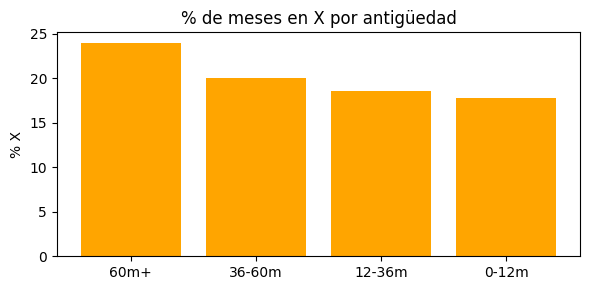

In [13]:
# ¿la ausencia (X) depende del tiempo?
isx = bb_t["STATUS"].astype(str).eq("X")
antig = pd.cut(bb_t["MONTHS_BALANCE"], [-97, -60, -36, -12, 1], labels=["60m+", "36-60m", "12-36m", "0-12m"])
pctx = isx.groupby(antig, observed=True).mean().mul(100).round(2)
print(pctx)

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(pctx.index.astype(str), pctx.values, color="orange")
ax.set(title="% de meses en X por antigüedad", ylabel="% X")
plt.tight_layout(); plt.show()

In [14]:
# ¿X carga señal a nivel cliente o enmascara la mora rara?
s = bb_t["STATUS"].astype(str)
bb_t["isX"], bb_t["isDPD"] = s.eq("X"), s.isin(["1", "2", "3", "4", "5"])

# default de X por recencia (nivel fila)
recbin = pd.cut(bb_t["MONTHS_BALANCE"], [-97, -24, -12, -6, 1], labels=["24m+", "12-24m", "6-12m", "0-6m"])
recX = bb_t.loc[bb_t["isX"]].groupby(recbin, observed=True)["TARGET"].mean().mul(100).round(2)
print("default de X por recencia:", recX.to_dict())

# nivel cliente: % de meses en X vs TARGET, y masking (X en créditos con/sin DPD)
g = bb_t.groupby("SK_ID_CURR")
cli = pd.DataFrame({"tot": g.size(), "nx": g["isX"].sum(), "ndpd": g["isDPD"].sum(), "TARGET": g["TARGET"].first()})
cli["pctX"], cli["has_dpd"] = cli["nx"] / cli["tot"] * 100, cli["ndpd"] > 0
x0, x1 = cli.loc[cli.TARGET == 0, "pctX"], cli.loc[cli.TARGET == 1, "pctX"]
u, pv = mannwhitneyu(x0, x1)
print(f"% meses en X vs TARGET (cliente): rank-biserial={abs(2*u/(len(x0)*len(x1))-1):.4f} (p={pv:.2f})")
print(f"% X medio (cliente) | CON DPD: {cli.loc[cli.has_dpd,'pctX'].mean():.2f}% vs SIN DPD: {cli.loc[~cli.has_dpd,'pctX'].mean():.2f}%")
# a nivel crédito el contraste es más marcado
gc = bb_t.groupby("SK_ID_BUREAU")
cred = pd.DataFrame({"tot": gc.size(), "nx": gc["isX"].sum(), "ndpd": gc["isDPD"].sum()})
cred["pctX"], cred["has_dpd"] = cred["nx"] / cred["tot"] * 100, cred["ndpd"] > 0
print(f"% X medio (crédito) | CON DPD: {cred.loc[cred.has_dpd,'pctX'].mean():.2f}% vs SIN DPD: {cred.loc[~cred.has_dpd,'pctX'].mean():.2f}%")

default de X por recencia: {'24m+': 6.25, '12-24m': 7.37, '6-12m': 7.92, '0-6m': 8.37}


% meses en X vs TARGET (cliente): rank-biserial=0.0085 (p=0.22)
% X medio (cliente) | CON DPD: 15.56% vs SIN DPD: 20.03%


% X medio (crédito) | CON DPD: 8.79% vs SIN DPD: 22.04%


`X` es el eje de missing de esta tabla, porque no hay un solo NaN en toda la tabla: la ausencia se codifica como un estado más. Con 2.837.039 crédito-mes (el 19,30% del histórico enlazado a train, y el 21,28% de la tabla completa), su tasa de default es 6,96%, que queda entre `C` (6,39%, crédito cerrado) y `0` (7,59%, activo al corriente) y muy por debajo de cualquier tramo de mora. Su aparición depende de la antigüedad del mes, del 17,77% en los meses más recientes (0 a 12) al 23,97% en los más antiguos (más de 60), en un crecimiento monótono: es el mismo deterioro de reporte con la antigüedad que observé en bureau, el buró deja de informar el estado de los meses viejos. Por eso lo clasifico como MAR, ya que la ausencia depende de una variable observada (el tiempo), y no como MNAR, porque no es un missing marcado por el riesgo oculto.

Antes de darlo por malo he comprobado que no esté enmascarando la señal de default, que es lo que más me importa preservar. Primero, a nivel cliente el porcentaje de meses en `X` no discrimina el default (rank-biserial 0,0085, p=0,22, con los bins de `X` todos en torno al 8%), así que como agregado es ruido. Segundo, y más decisivo, `X` y la mora están inversamente relacionados: los créditos con algún DPD tienen mucho menos `X` (8,79%) que los que nunca lo tuvieron (22,04%), y a nivel cliente igual (15,56% frente a 20,03%). Un crédito con mucho `X` es uno que el buró ya no sigue (inactivo o cerrado, de bajo riesgo), no uno con problemas escondidos. El único matiz es que el `X` reciente no es tan plano: su default sube del 6,25% a más de 24 meses al 8,37% en los últimos 6, pero eso replica el efecto general de recencia y ni siquiera el `X` reciente alcanza los tramos de mora.

La consecuencia para la agregación a nivel cliente es que cuando construya algo similar a "% de meses en mora" no puedo dividir por el total de meses (que incluye `X`), porque el `X` inflado de los historiales largos hincharía el denominador y aplastaría la señal de los pocos meses en DPD; el ratio tiene que normalizarse por los meses **reportados** (`0` a `5`). Y como acabo de comprobar que `X` no esconde mora, sacarlo del denominador es seguro. `X` es además un fenómeno distinto de no tener ningún histórico mensual: uno es ausencia dentro del histórico, el otro es no tener histórico. 

### 6. Análisis Correlaciones

,n,tasa
STATUS,,
C,7027575,6.39
X,2837039,6.96
0,4615684,7.59
1,155330,10.24
2,15583,10.40
3,5976,11.33
4,3897,11.98
5,40528,11.39


Chi2 = 10,753 | V de Cramér = 0.0270 | escalón de 0 a 1: +2.65pp | masa en C, X y 0: 98.49% (en mora 1.51%)


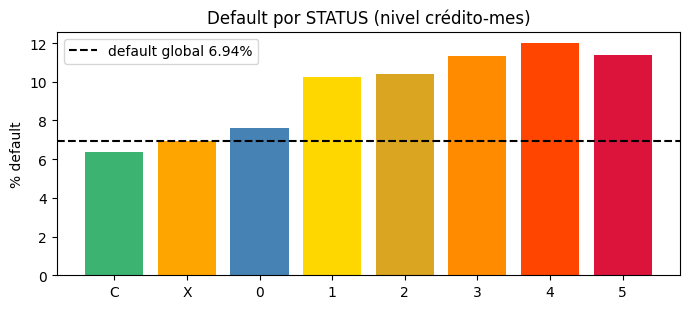

In [15]:
# jerarquía de riesgo por STATUS (nivel crédito-mes, TARGET heredado)
tab = bb_t.groupby("STATUS", observed=True)["TARGET"].agg(n="size", tasa="mean").reindex(orden)
tab["tasa"] = (tab["tasa"] * 100).round(2)
display(tab)

ct = pd.crosstab(bb_t["STATUS"], bb_t["TARGET"])
base = bb_t["TARGET"].mean() * 100
sin_mora = tab.loc[["C", "X", "0"], "n"].sum() / len(bb_t) * 100  # masa pegada a la base que diluye la V
print(f"Chi2 = {chi2_contingency(ct).statistic:,.0f} | V de Cramér = {association(ct, method='cramer', correction=True):.4f} | "
      f"escalón de 0 a 1: {tab.loc['1', 'tasa'] - tab.loc['0', 'tasa']:+.2f}pp | "
      f"masa en C, X y 0: {sin_mora:.2f}% (en mora {100 - sin_mora:.2f}%)")

fig, ax = plt.subplots(figsize=(7, 3.2))
colores = ["mediumseagreen", "orange", COLOR_NODEF, "gold", "goldenrod", "darkorange", "orangered", COLOR_DEF]
ax.bar(orden, tab["tasa"], color=colores)
ax.axhline(base, color="black", ls="--", label=f"default global {base:.2f}%")
ax.set(title="Default por STATUS (nivel crédito-mes)", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [16]:
# ¿la escala ordinal aporta sobre la binaria? (solo meses reportados: C y X quedan fuera de escala)
bb_t["dpd"] = pd.to_numeric(bb_t["STATUS"], errors="coerce")  # C y X salen NaN
rep = bb_t["dpd"].notna()
d, t = bb_t.loc[rep, "dpd"].values, bb_t.loc[rep, "TARGET"].values
print(f"meses reportados: {rep.sum():,} ({rep.mean() * 100:.2f}% del histórico enlazado)")

for nombre, v in [("escala de 0 a 5", d), ("binaria DPD > 0", (d > 0).astype(float))]:
    x0, x1 = v[t == 0], v[t == 1]
    u, p = mannwhitneyu(x0, x1)
    r_rb = abs(2 * u / (len(x0) * len(x1)) - 1)
    print(f"{nombre}: Pearson={pearsonr(v, t)[0]:.4f} | Spearman={spearmanr(v, t)[0]:.4f} | rank-biserial={r_rb:.4f} (p={p:.1e})")

meses reportados: 4,836,998 (32.90% del histórico enlazado)


escala de 0 a 5: Pearson=0.0201 | Spearman=0.0230 | rank-biserial=0.0180 (p=0.0e+00)


binaria DPD > 0: Pearson=0.0229 | Spearman=0.0229 | rank-biserial=0.0180 (p=0.0e+00)


créditos: 523,515


,Pearson,Spearman,n
meses_obs,-0.0619,-0.0692,523515
rec_dpd,0.0565,0.0604,67962
pct_dpd,0.0323,0.0341,456399
worst,0.0277,0.0326,456399
n_rep,-0.0188,-0.0187,523515
n_dpd,0.0155,0.0292,523515
pct_X,0.0045,0.0051,523515


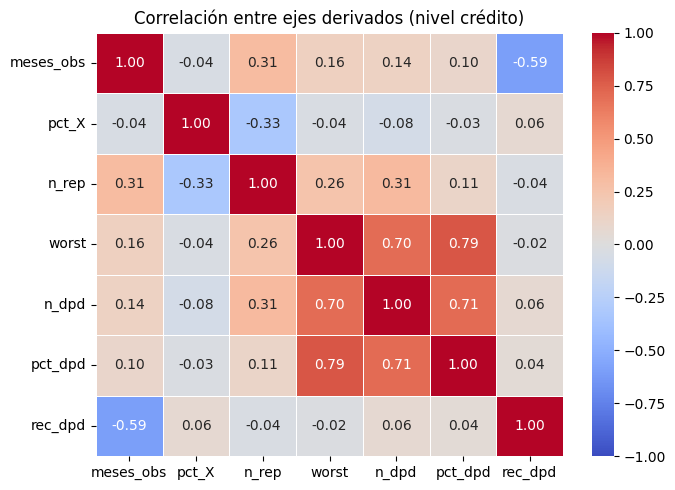

r
worst     pct_dpd  0.7882
n_dpd     pct_dpd  0.7087
worst     n_dpd    0.6976
meses_obs rec_dpd -0.5940
pct_X     n_rep   -0.3261
n_rep     n_dpd    0.3133
meses_obs n_rep    0.3121
n_rep     worst    0.2567
meses_obs worst    0.1562
          n_dpd    0.1354
n_rep     pct_dpd  0.1124
meses_obs pct_dpd  0.0953
pct_X     n_dpd   -0.0769
          rec_dpd  0.0650
n_dpd     rec_dpd  0.0641
meses_obs pct_X   -0.0406
pct_dpd   rec_dpd  0.0397
pct_X     worst   -0.0362
n_rep     rec_dpd -0.0357
pct_X     pct_dpd -0.0309
worst     rec_dpd -0.0178

In [17]:
# ejes derivados a nivel crédito (precursores de las features de la Fase B)
credf = bb_t.groupby("SK_ID_BUREAU").agg(
    meses_obs=("STATUS", "size"),  # exposición
    pct_X=("isX", "mean"),         # ausencia de reporte
    n_rep=("dpd", "count"),        # meses con estado reportado (0 a 5)
    worst=("dpd", "max"),          # severidad
    n_dpd=("isDPD", "sum"),        # intensidad bruta
    TARGET=("TARGET", "first"),
)
credf["pct_X"] *= 100
credf["pct_dpd"] = credf["n_dpd"] / credf["n_rep"] * 100  # intensidad normalizada por meses reportados
credf["rec_dpd"] = bb_t.loc[bb_t["isDPD"]].groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].max()  # recencia del último DPD
ejes = ["meses_obs", "pct_X", "n_rep", "worst", "n_dpd", "pct_dpd", "rec_dpd"]

# ranking contra TARGET heredado, con la población de cada medición (worst y rec_dpd no existen en todo crédito)
rank = pd.DataFrame({
    "Pearson": credf[ejes].corrwith(credf["TARGET"]),
    "Spearman": credf[ejes].corrwith(credf["TARGET"], method="spearman"),
    "n": credf[ejes].notna().sum(),
}).sort_values("Pearson", key=abs, ascending=False)
print(f"créditos: {len(credf):,}")
display(rank.round(4))

m = credf[ejes].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(m, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=.5, ax=ax)
ax.set_title("Correlación entre ejes derivados (nivel crédito)")
plt.tight_layout(); plt.show()

# pares ordenados por |r| para leer las hipótesis del bloque (el heatmap solo da 2 decimales)
pares = m.where(np.triu(np.ones(m.shape), k=1).astype(bool)).stack().sort_values(key=abs, ascending=False)
display(pares.round(4).to_frame("r"))

In [18]:
# si la feature entra como flag, la redundancia se mide sobre la binarizada, no sobre el valor crudo
flags = pd.DataFrame({  # sin mes reportado (NaN) la comparación ya da False: no hay evidencia de mora
    "has_dpd": credf["n_dpd"] > 0,
    "grave": credf["worst"] >= 3,
    "writeoff": credf["worst"] == 5,
    "recent_dpd": credf["rec_dpd"] >= -6,
})


def tasa(mask):
    """tasa de default y n de un subconjunto de créditos."""
    return f"{credf.loc[mask, 'TARGET'].mean() * 100:.2f}% (n={int(mask.sum()):,})"


filas = []
for a, b in combinations(flags, 2):
    A, B = flags[a], flags[b]
    inter = int((A & B).sum())
    filas.append({"par": f"{a} vs {b}",
                  "V de Cramér": round(association(pd.crosstab(A, B), method="cramer", correction=True), 4),
                  "Jaccard": round(inter / int((A | B).sum()), 4),
                  "n_1": int(A.sum()), "n_2": int(B.sum()), "comunes": inter})
display(pd.DataFrame(filas))

for c in flags:
    delta = credf.loc[flags[c], "TARGET"].mean() - credf.loc[~flags[c], "TARGET"].mean()
    print(f"{c}: {tasa(flags[c])} vs {tasa(~flags[c])} | delta {delta * 100:+.2f}pp")

# en los pares anidados, ¿la flag ancha tiene señal propia o prestada de la estrecha?
print()
for ancha, estrecha in [("grave", "writeoff"), ("has_dpd", "recent_dpd")]:
    grupos = {"ninguna": ~flags[ancha],
              f"{ancha} sin {estrecha}": flags[ancha] & ~flags[estrecha],
              estrecha: flags[estrecha]}
    print(" | ".join(f"{k} {tasa(v)}" for k, v in grupos.items()))

,par,V de Cramér,Jaccard,n_1,n_2,comunes
0,has_dpd vs grave,0.2713,0.0837,67962,5686,5686
1,has_dpd vs writeoff,0.2146,0.0526,67962,3573,3573
2,has_dpd vs recent_dpd,0.4504,0.2263,67962,15377,15377
3,grave vs writeoff,0.7910,0.6284,5686,3573,3573
4,grave vs recent_dpd,0.1500,0.0790,5686,15377,1542
5,writeoff vs recent_dpd,0.1460,0.0657,3573,15377,1168


has_dpd: 10.34% (n=67,962) vs 7.97% (n=455,553) | delta +2.37pp
grave: 11.01% (n=5,686) vs 8.24% (n=517,829) | delta +2.77pp
writeoff: 12.12% (n=3,573) vs 8.25% (n=519,942) | delta +3.87pp
recent_dpd: 13.19% (n=15,377) vs 8.12% (n=508,138) | delta +5.06pp

ninguna 8.24% (n=517,829) | grave sin writeoff 9.13% (n=2,113) | writeoff 12.12% (n=3,573)
ninguna 7.97% (n=455,553) | has_dpd sin recent_dpd 9.50% (n=52,585) | recent_dpd 13.19% (n=15,377)


La jerarquía por `STATUS` a nivel crédito-mes sale nítida y en tres bloques. Los estados sin mora viva quedan en la base o por debajo, con `C` en 6,39% (n=7.027.575, crédito saldado) y `X` en 6,96% (n=2.837.039) frente al 6,94% global, y `0` sube ligeramente hasta 7,59% (n=4.615.684). El salto lo dan los tramos de DPD: `1` con 10,24%, `2` con 10,40%, `3` con 11,33%, `4` con 11,98% y `5` con 11,39%. El dato que manda es el escalón de `0` a `1`, que vale **+2,65pp**, más que todo el recorrido interno de la mora (de 10,24% a 11,98%, 1,74pp). Cualquier mes en mora, aunque sea el tramo más leve de 1 a 30 días, pesa más que la diferencia entre ser leve o ser grave.

Esto matiza lo que anticipé y es que dije que la severidad fina no sería fiablemente monótona, y de `1` a `4` sí lo es; quien rompe la escala es `5` (11,39%, por debajo del 11,98% de `4`). El motivo no era el que supuse: `5` no es "más días de retraso" sino un estado distinto (fallido), y de hecho a nivel crédito se comporta como el más severo de todos (12,12%). El Chi2 de 10.753 con V de Cramér de 0,0270 reproduce el patrón de Chi2 grande con V pequeña que ya vi en bureau, y se explica porque el 98,49% del histórico enlazado está en `C`, `X` o `0` pegado a la base mientras solo el 1,51% concentra la señal.

Sobre los 4.836.998 meses reportados (32,90% del histórico enlazado) probé si la escala ordinal aporta algo como numérica. La escala de 0 a 5 da Pearson 0,0201 y Spearman 0,0230, un ratio de 1,14 es casi lineal. Y la comparación de codificaciones es la que decide, porque la binaria `DPD > 0` da Pearson 0,0229, un 14% más que la escala completa, con rank-biserial idéntico (0,0180) en las dos. El orden de rangos es el mismo y la distancia entre tramos no aporta nada. Binarizar la mora no pierde información, la gana, lo que cierra la decisión de encoding que aplicaré.

Al bajar a nivel crédito (523.515 créditos) el ranking contra el `TARGET` heredado lo encabezan los meses observados con Pearson -0,0619, seguidos de la recencia del último impago con +0,0565 (n=67.962), el porcentaje de meses en mora con +0,0323, el peor estado alcanzado con +0,0277, los meses con estado reportado con -0,0188, el número de meses en mora con +0,0155 y el porcentaje de meses sin reportar con +0,0045.

La primera hipótesis que barajaba era el sesgo de exposición, y queda refutada. Esperaba que el conteo bruto de meses en mora estuviese inflado por la duración de la observación, y su correlación con los meses observados es de solo 0,1354. Normalizar sigue mereciendo la pena, porque el porcentaje rinde 0,0323 frente al 0,0155 del conteo bruto, pero no por el motivo que supuse, ya que el denominador informativo no depende de lo que dura el crédito sino de cuánto reporta el buró, como muestran el 0,3121 entre meses observados y meses reportados y el -0,3261 entre el porcentaje de meses sin reportar y los meses reportados.

La segunda hipótesis era que severidad e intensidad fuesen ejes distintos, y también cae. El peor estado alcanzado y el porcentaje de meses en mora correlacionan 0,7882, el conteo de meses en mora y ese porcentaje 0,7087, ambos por encima del umbral de 0,70, y el peor estado con el conteo se queda en 0,6976, justo por debajo. Los tres colapsan en un único eje de "cuánta mora acumula el crédito", así que llevarlos los tres a la agregación sería triplicar la misma variable.

La tercera sí se confirma, y es la más útil: la recencia es un eje propio. La recencia del último impago correlaciona -0,0178 con el peor estado alcanzado, prácticamente cero, y aun así es la segunda del ranking pese a existir solo en 67.962 créditos, el 13,0% del total. Queda un aviso, y es que correlaciona -0,5940 con los meses observados, por debajo del umbral pero lo bastante alto como para tenerlo presente: un histórico largo permite que el último DPD quede lejos por pura ventana de observación.

La cuarta, que `X` fuese inverso a la mora, se confirma solo en presencia. El porcentaje de meses sin reportar correlaciona -0,0769 con el conteo de meses en mora y 0,0045 con el `TARGET`, o sea ruido. El contraste de medias entre créditos con y sin mora (8,79% de meses en `X` en los créditos con DPD frente al 22,04% en los que nunca lo tuvieron) se sostiene en el signo, pero como continua no hay gradiente, lo que confirma descartar `X` como predictor y conservarlo solo como criterio para el denominador del ratio.

El bloque de flags es el que más cambia mis prioridades, y lo mido sobre la versión binarizada y no sobre el valor crudo. Los deltas ordenan el impago reciente en +5,06pp (13,19%, n=15.377), el fallido en +3,87pp (12,12%, n=3.573), el impago grave en +2,77pp (11,01%, n=5.686) y el haber tenido algún impago en +2,37pp (10,34%, n=67.962). La recencia gana a la severidad, que es el orden contrario al que sugería la jerarquía de `STATUS` a nivel mes.

Los dos pares anidados los resuelvo con la partición residual, para separar señal propia de señal prestada. El impago grave y el fallido dan V de Cramér de 0,7910, por encima del umbral de 0,50, y los 3.573 créditos fallidos están todos dentro de los 5.686 graves. Al quitarle el fallido, el resto de graves cae a 9,13% (n=2.113) frente al 12,12% del fallido: la señal del grave era prestada, así que conservo el fallido. El par de haber tenido algún impago y haberlo tenido hace poco da V de Cramér de 0,4504 con Jaccard de 0,2263, también anidado, pero el reciente es solo el 22,6% del total, y la partición sale limpia y monótona con sin mora en 7,97% (n=455.553), mora antigua en 9,50% (n=52.585) y mora reciente en 13,19% (n=15.377). Aquí la flag genérica sí tiene señal propia, porque la mora antigua aporta +1,53pp sobre los créditos limpios, pero se queda corta al fusionar dos poblaciones que se separan entre sí por 3,69pp.

En resumen, de aquí salen tres decisiones para la agregación a nivel cliente:

- Codificar la mora como binaria y no como escala de 0 a 5, porque la escala fina no aporta y el escalón está en tener o no tener mora.
- No llevar severidad e intensidad como ejes separados, porque con correlaciones de 0,70 a 0,79 son un solo eje.
- Tratar la recencia como eje independiente, que es donde está la señal más fuerte y donde no hay solape con la severidad.

Todo esto está medido a nivel crédito, ya que los créditos de un mismo cliente comparten `TARGET` y los p-valores salen anticonservadores. La decisión final de redundancia se toma sobre la feature ya agregada a nivel cliente. El gradiente completo de default por tramos de recencia y el papel de `MONTHS_BALANCE` los dejo para el eje temporal.

### 7. Análisis Temporal

créditos con huecos en la ventana: 0 | llegan al mes 0: 66.03% | censurados: 33.97%
default | llega a 0: 8.28% (n=345,670) | censurado: 8.25% (n=177,845)
mediana de la recencia (n=67,962) | absoluta: -15 vs -39 | relativa al fin de ventana: -15 vs -10


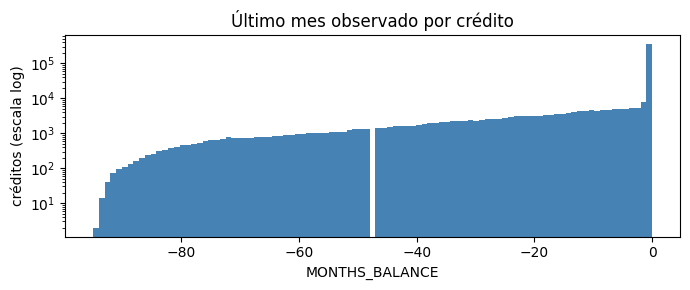

In [19]:
# ¿el histórico de cada crédito llega al mes de la solicitud?
ventana = bb_t.groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].agg(["min", "max"])
credf["fin"] = ventana["max"]
credf["ini"] = credf["fin"] - credf["meses_obs"] + 1 
credf["censurado"] = credf["fin"] < 0
print(f"créditos con huecos en la ventana: {int((ventana['min'] != credf['ini']).sum())} | "
      f"llegan al mes 0: {(~credf['censurado']).mean() * 100:.2f}% | censurados: {credf['censurado'].mean() * 100:.2f}%")
print(f"default | llega a 0: {tasa(~credf['censurado'])} | censurado: {tasa(credf['censurado'])}")

# qué le hace la censura a la recencia del último DPD
con = credf[credf["rec_dpd"].notna()]
rel = con["rec_dpd"] - con["fin"]  # meses entre el último DPD y el fin de su ventana
print(f"mediana de la recencia (n={len(con):,}) | absoluta: {con.loc[~con['censurado'], 'rec_dpd'].median():.0f} "
      f"vs {con.loc[con['censurado'], 'rec_dpd'].median():.0f} | "
      f"relativa al fin de ventana: {rel[~con['censurado']].median():.0f} vs {rel[con['censurado']].median():.0f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(credf["fin"], bins=97, color=COLOR_NODEF, log=True)  # el 66% se apila en 0 y aplasta la cola
ax.set(title="Último mes observado por crédito", xlabel="MONTHS_BALANCE", ylabel="créditos (escala log)")
plt.tight_layout(); plt.show()

,n,tasa
bin,,
24m+,33829,8.86
12-24m,12271,10.36
6-12m,7894,11.22
3-6m,4915,12.66
0-3m,9053,13.81


recencia vs TARGET: rank-biserial=0.1144 (p=8.5e-56, n=67,962)


size           mean        
censurado  False  True    False   True 
bin                                    
24m+       17109  16720  0.0781  0.0992
12-24m      8376   3895  0.0924  0.1276
6-12m       6338   1556  0.1021  0.1536
3-6m        4413    502  0.1147  0.2311
0-3m        8892    161  0.1363  0.2360

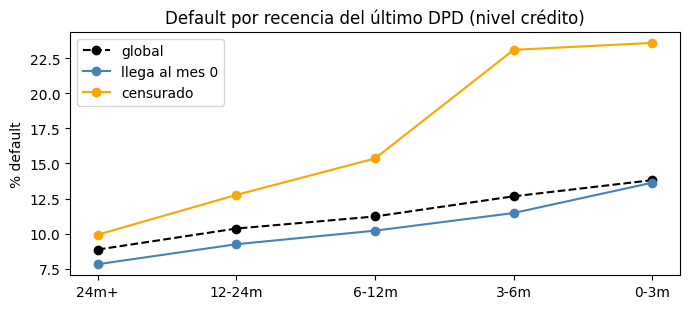

In [20]:
# gradiente de default por recencia del último DPD (solo créditos con algún DPD)
con = credf[credf["rec_dpd"].notna()].copy()
con["bin"] = pd.cut(con["rec_dpd"], [-97, -24, -12, -6, -3, 1], labels=["24m+", "12-24m", "6-12m", "3-6m", "0-3m"])
tabr = con.groupby("bin", observed=True)["TARGET"].agg(n="size", tasa="mean")
tabr["tasa"] = (tabr["tasa"] * 100).round(2)
display(tabr)

x0, x1 = con.loc[con["TARGET"] == 0, "rec_dpd"], con.loc[con["TARGET"] == 1, "rec_dpd"]
u, p = mannwhitneyu(x0, x1)
print(f"recencia vs TARGET: rank-biserial={abs(2 * u / (len(x0) * len(x1)) - 1):.4f} (p={p:.1e}, n={len(con):,})")

# ¿riesgo real o debido a la ventana? el mismo corte dentro de cada estrato de censura
estr = con.pivot_table(index="bin", columns="censurado", values="TARGET", aggfunc=["size", "mean"], observed=True)
display(estr.round(4))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(tabr.index.astype(str), tabr["tasa"], "o--", color="black", label="global")
for cens, etiqueta, color in [(False, "llega al mes 0", COLOR_NODEF), (True, "censurado", "orange")]:
    ax.plot(tabr.index.astype(str), estr[("mean", cens)] * 100, "o-", color=color, label=etiqueta)
ax.set(title="Default por recencia del último DPD (nivel crédito)", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [21]:
# ¿la mora reciente es señal propia o historial corto?
credf["estrato"] = pd.cut(credf["meses_obs"], [0, 12, 24, 48, 97], labels=["0-12m", "13-24m", "25-48m", "49m+"])
for e in credf["estrato"].cat.categories:
    en_estrato = credf["estrato"].eq(e)
    reciente, resto = en_estrato & flags["recent_dpd"], en_estrato & ~flags["recent_dpd"]
    delta = credf.loc[reciente, "TARGET"].mean() - credf.loc[resto, "TARGET"].mean()
    print(f"{e}: mora reciente {tasa(reciente)} vs resto {tasa(resto)} | delta {delta * 100:+.2f}pp")

0-12m: mora reciente 14.56% (n=7,061) vs resto 10.55% (n=146,548) | delta +4.01pp
13-24m: mora reciente 12.96% (n=5,092) vs resto 8.37% (n=125,694) | delta +4.60pp
25-48m: mora reciente 10.32% (n=2,538) vs resto 6.87% (n=146,183) | delta +3.46pp
49m+: mora reciente 11.37% (n=686) vs resto 5.87% (n=89,713) | delta +5.50pp


In [22]:
# ¿el riesgo está en el deterioro reciente o basta con haber tenido mora?
medio = (credf["ini"] + credf["fin"]) / 2
bb_t["mitad_reciente"] = bb_t["MONTHS_BALANCE"].values > bb_t["SK_ID_BUREAU"].map(medio).values
mitad = bb_t.groupby(["SK_ID_BUREAU", "mitad_reciente"])["dpd"].max().unstack(fill_value=0)
tray = credf.join(mitad.set_axis(["w_ant", "w_rec"], axis=1))  # sin mes reportado en una mitad cuenta como 0
tray = tray[tray["meses_obs"] >= 6].fillna({"w_ant": 0, "w_rec": 0})  # ventanas cortas no admiten partición
tray["trayectoria"] = np.select(
    [(tray["w_rec"] == 0) & (tray["w_ant"] == 0), tray["w_rec"] > tray["w_ant"], tray["w_rec"] < tray["w_ant"]],
    ["sin mora", "empeora", "mejora"], default="estable")

tabt = tray.groupby("trayectoria")["TARGET"].agg(n="size", tasa="mean").reindex(["sin mora", "mejora", "estable", "empeora"])
tabt["tasa"] = (tabt["tasa"] * 100).round(2)
display(tabt)
print(f"población: {len(tray):,} créditos con ventana de 6 meses o más")

# ¿mejora real o el crédito deja de reportarse? una mitad sin ningún mes reportado no es comparable
nrep = bb_t.groupby(["SK_ID_BUREAU", "mitad_reciente"])["dpd"].count().unstack(fill_value=0)
tray[["r_ant", "r_rec"]] = nrep.set_axis(["r_ant", "r_rec"], axis=1).reindex(tray.index).fillna(0)
tray["ciega"] = (tray["r_ant"] == 0) | (tray["r_rec"] == 0)
comp = tray[~tray["ciega"]].groupby("trayectoria")["TARGET"].agg(n="size", tasa="mean")
comp["tasa"] = (comp["tasa"] * 100).round(2)
comp["% con una mitad sin reportar"] = (tray.groupby("trayectoria")["ciega"].mean() * 100).round(2)
display(comp.reindex(["sin mora", "mejora", "estable", "empeora"]))

,n,tasa
trayectoria,,
sin mora,404631,7.46
mejora,39931,8.94
estable,9105,12.40
empeora,17095,11.91


población: 470,762 créditos con ventana de 6 meses o más


,n,tasa,% con una mitad sin reportar
trayectoria,,,
sin mora,157225,8.14,61.14
mejora,13664,9.57,65.78
estable,9105,12.40,0.00
empeora,16380,11.98,4.18


Antes de medir nada he controlado la ventana de observación, porque la forma del histograma mensual sugería que cada crédito se sigue hasta el mes de la solicitud, y **eso es falso para un tercio de la tabla**: solo el 66,03% llega al mes 0, y 177.845 créditos (33,97%) dejan de reportarse antes. Lo que sí se confirma es que la ventana es perfectamente contigua, con 0 créditos con huecos, así que los meses observados se leen literalmente como una ventana continua y puedo derivar su inicio del final y la longitud.

Esa censura no es riesgo. Los créditos que llegan al mes 0 dan 8,28% de default (n=345.670) y los censurados 8,25% (n=177.845), prácticamente idénticos, así que depende de cómo reporta el buró y no de una característica del cliente. Pero sí **degrada la medición de la recencia**: la mediana del último DPD es de -15 meses en los que llegan al mes 0 y de -39 en los censurados, mientras que medida relativa al fin de su propia ventana las dos convergen (-15 y -10). Es decir, no es que los censurados tuvieran su mora más antigua, es que dejaron de observarse antes. Ahí está la explicación mecánica del -0,5940 entre recencia y meses observados que había dejado anotado como confusor pendiente.

Con eso controlado, el gradiente de recencia sale monótono y limpio sobre los 67.962 créditos con algún DPD: 8,86% cuando el último impago fue hace más de 24 meses (n=33.829), 10,36% entre 12 y 24, 11,22% entre 6 y 12, 12,66% entre 3 y 6, y 13,81% en los últimos 3 meses (n=9.053). Un span de +4,95pp explicado solo por cuándo, con rank-biserial de 0,1144 (efecto moderado, p=8,5e-56), del mismo orden que el 0,1502 de la longitud de histórico.

El contraste que decide el bloque es el estratificado, porque ese gradiente podría venir de la ventana de observación y no del riesgo. No es el caso: **se sostiene en los dos estratos de censura**, de 7,81% a 13,63% en los créditos que llegan al mes 0 (+5,82pp) y de 9,92% a 23,60% en los censurados (+13,68pp). Y ahí aparece algo que no anticipé, y es que en los censurados el gradiente es mucho más pronunciado. Un crédito que entra en mora justo antes de que el buró deje de seguirlo llega al 23,60% de default, casi el triple de la base. La lectura de negocio es que dejar de reportar un crédito recién impagado apunta a un cierre problemático (venta o traspaso a recobro), lo que enlaza con las categorías 'Sold' y 'Bad debt' de bureau. Lo tomo como indicativo y no como cifra firme, porque esos dos bins tienen n de 161 y 502. El matiz metodológico es que la censura por sí sola no discrimina, pero **interactúa** con la recencia.

Quedaba pendiente saber si la mora reciente no sería simplemente "crédito joven" disfrazado. El test en cuatro estratos de longitud de ventana lo descarta, porque el delta aguanta en los cuatro: +4,01pp de 0 a 12 meses, +4,60pp de 13 a 24, +3,46pp de 25 a 48 y +5,50pp en 49 o más. Y el delta **mayor** está en los históricos largos, justo lo contrario de lo que exigiría la hipótesis de confusión: en un crédito con 49 meses o más de ventana, tener mora en los últimos 6 casi dobla el riesgo (11,37% frente a 5,87%). Es señal propia, el mismo patrón que rescató `BUREAU_DAYS_CREDIT_UPDATE_FLAG` en bureau.

Por último la trayectoria, que es la única pregunta que solo un histórico mensual puede responder. Esperaba que el deterioro reciente concentrase el riesgo por encima de la recuperación, y se confirma pero con un matiz que no había anticipado. Sobre los 470.762 créditos con ventana de 6 meses o más, sin mora da 7,46% (n=404.631), mejora 8,94% (n=39.931), empeora 11,91% (n=17.095) y **estable 12,40% (n=9.105), que es el más alto de los cuatro**. La mora **persistente**, la que se mantiene en el mismo nivel en las dos mitades de la ventana, pesa más que el deterioro puntual. Y en el extremo opuesto, recuperarse recorta casi todo el exceso de riesgo, porque "mejora" queda a solo +1,48pp de los créditos limpios, mucho más cerca de ellos que de la mora viva.

Hay que mirar de qué está hecha cada categoría antes de darla por buena, porque una mitad de la ventana puede no tener ni un mes con estado reportado. Ahí está el matiz que faltaba: el 65,78% de los créditos que "mejoran" no tiene ningún mes reportado en su mitad reciente, así que no es que mejoren, es que dejan de reportarse, casi siempre porque se cierran. En "empeora" pasa en el 4,18% y en "estable" en ninguno, que es lo coherente con exigir mora viva en las dos mitades. Restringiendo a los créditos con las dos mitades reportadas, que es la comparación limpia, el orden se mantiene entero: 8,14% sin mora (n=157.225), 9,57% mejora (n=13.664), 11,98% empeora (n=16.380) y 12,40% estable (n=9.105). La jerarquía aguanta, pero la etiqueta induce a error, así que la feature tendrá que exigir meses reportados en las dos mitades, o nombrar esa categoría por lo que de verdad contiene, que es mora seguida de cierre.

Eso es información que el peor estado agregado no contiene, porque marca igual a un crédito que se recuperó y a uno que sigue en mora. La trayectoria es por tanto una feature candidata nueva, además de las dos temporales que ya tenía previstas.

En resumen, de aquí salen tres cosas para la agregación a nivel cliente:

- La recencia del último DPD es la señal temporal principal, y es propia, no prestada de la longitud del historial.
- La censura de ventana no es predictor por sí sola, pero hay que llevarla como control, porque desplaza la recencia absoluta e interactúa con ella.
- La trayectoria (sin mora, mejora, estable, empeora) separa mora resuelta de mora persistente y merece entrar como feature propia, definida sobre créditos con las dos mitades de la ventana reportadas.

### 8. Análisis de Outliers

In [23]:
# validez de dominio de las columnas crudas
fuera_mes = int(((bb["MONTHS_BALANCE"] < -96) | (bb["MONTHS_BALANCE"] > 0)).sum())
fuera_status = int((~bb["STATUS"].astype(str).isin(orden)).sum())
print(f"MONTHS_BALANCE fuera de [-96, 0]: {fuera_mes} | STATUS fuera del dominio: {fuera_status}")


ev_cred = EvaluadorSenal(credf, credf["TARGET"])  # instancia propia: no contamina el ranking de la Fase B

# ¿el cierre es absorbente?
esC = bb_t["STATUS"].astype(str).eq("C")
primer_C = bb_t.loc[esC].groupby("SK_ID_BUREAU")["MONTHS_BALANCE"].min()
nC = esC.groupby(bb_t["SK_ID_BUREAU"]).sum()
nX = bb_t["isX"].groupby(bb_t["SK_ID_BUREAU"]).sum()
assert (nC + nX + credf["n_rep"] == credf["meses_obs"]).all(), "C, X y meses reportados no cubren la ventana"

reabre = (bb_t["MONTHS_BALANCE"] > bb_t["SK_ID_BUREAU"].map(primer_C)) & ~esC
print(f"créditos con algún C: {len(primer_C):,} | con estado no-C posterior a su primer C: "
      f"{bb_t.loc[reabre, 'SK_ID_BUREAU'].nunique()} ({int(reabre.sum())} filas: "
      f"{bb_t.loc[reabre, 'STATUS'].astype(str).value_counts().to_dict()})")

# ¿la ventana mensual cuadra con la fecha de apertura del crédito en bureau?
dc = bureau.set_index("SK_ID_BUREAU")["DAYS_CREDIT"].reindex(credf.index)
desfase = credf["meses_obs"] - (-dc / 30.44 + credf["fin"])  # observados menos transcurridos desde la apertura
previos = desfase > 1
print(f"desfase mediana {desfase.median():.1f} meses (p95 {desfase.quantile(.95):.1f}) | ventana anterior a la "
      f"apertura: {int(previos.sum()):,} créditos ({previos.mean() * 100:.2f}%), exceso máximo {desfase.max():.1f} meses")
ev_cred.evaluar_flags([("ventana previa a la apertura", previos, None, "todos los créditos")])

MONTHS_BALANCE fuera de [-96, 0]: 0 | STATUS fuera del dominio: 0


créditos con algún C: 278,937 | con estado no-C posterior a su primer C: 5 (6 filas: {'1': 5, '2': 1})
desfase mediana 0.5 meses (p95 1.0) | ventana anterior a la apertura: 16,014 créditos (3.06%), exceso máximo 1.1 meses


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
ventana previa a la apertura,todos los créditos,8.3% (n=16014),8.27% (n=507501),+0.03 pp,0.1,0.9039170548247353


In [24]:
# la pérdida al cruzar con bureau: ¿qué perfil tienen los créditos huérfanos?
huerfano = ~bb["SK_ID_BUREAU"].isin(bureau["SK_ID_BUREAU"])
print(f"filas huérfanas: {int(huerfano.sum()):,} ({huerfano.mean() * 100:.2f}% de la tabla)")

perfil = []
for nombre, sub in [("huérfanos", bb[huerfano]), ("con padre en bureau", bb[~huerfano])]:
    s = sub["STATUS"].astype(str)
    meses = sub.groupby("SK_ID_BUREAU").size()
    perfil.append({"grupo": nombre, "créditos": sub["SK_ID_BUREAU"].nunique(),
                   "meses (mediana)": meses.median(), "meses (media)": round(meses.mean(), 1),
                   "% C": round(s.eq("C").mean() * 100, 2), "% X": round(s.eq("X").mean() * 100, 2),
                   "% DPD": round(s.isin(["1", "2", "3", "4", "5"]).mean() * 100, 2)})
display(pd.DataFrame(perfil))

filas huérfanas: 3,120,184 (11.43% de la tabla)


,grupo,créditos,meses (mediana),meses (media),% C,% X,% DPD
0,huérfanos,43041,97.0,72.5,67.03,22.29,0.93
1,con padre en bureau,774354,25.0,31.2,47.79,21.15,1.30


In [25]:
# C y X no son mora, pero tampoco son ausencia de mora: ¿cuántos créditos se quedan sin denominador?
sin_rep = credf["n_rep"].eq(0)
solo_X = credf["pct_X"].eq(100)
print(f"créditos sin ningún estado numérico (solo C y X): {int(sin_rep.sum()):,} ({sin_rep.mean() * 100:.2f}%), "
      f"de los cuales 100% X: {int(solo_X.sum()):,}")

# el extremo del ratio de intensidad, ¿riesgo máximo o denominador de un solo mes?
lleno = credf["pct_dpd"].eq(100)
con_dpd = credf["n_dpd"] > 0
print(f"pct_dpd = 100%: {int(lleno.sum()):,} créditos | meses reportados que lo producen: "
      f"{credf.loc[lleno, 'n_rep'].value_counts().head(4).to_dict()}")
print(f"créditos con un mes reportado o menos: {int(credf['n_rep'].le(1).sum()):,} ({credf['n_rep'].le(1).mean() * 100:.2f}%)")

ev_cred.evaluar_flags([("sin estado numérico", sin_rep, None, "todos los créditos"),
                       ("pct_dpd = 100%", lleno, con_dpd, "créditos con mora")])

créditos sin ningún estado numérico (solo C y X): 67,116 (12.82%), de los cuales 100% X: 47,488
pct_dpd = 100%: 729 créditos | meses reportados que lo producen: {1: 280, 2: 78, 4: 71, 3: 53}
créditos con un mes reportado o menos: 93,033 (17.77%)


Variable,Población,Tasa (1),Tasa (0),Delta,z-stat,p-valor
sin estado numérico,todos los créditos,8.8% (n=67116),8.2% (n=456399),+0.61 pp,5.3,1.0448313121535301e-07
pct_dpd = 100%,créditos con mora,10.01% (n=729),10.34% (n=67233),-0.33 pp,-0.3,0.7733776264700399


,50%,90%,95%,99%,max,Máx/p99,severo
meses_obs,22.0,60.0,77.00,91.00,97.0,1.07,no
n_rep,7.0,21.0,28.00,47.00,96.0,2.04,no
n_dpd,0.0,1.0,2.00,8.00,89.0,11.12,sí
pct_dpd,0.0,10.0,23.08,63.64,100.0,1.57,no
worst,0.0,1.0,1.00,3.00,5.0,1.67,no


,n,tasa
n_dpd,,
0,455553,7.97
1,32862,9.94
2-3,19644,10.69
4-8,10566,10.97
9+,4890,10.27


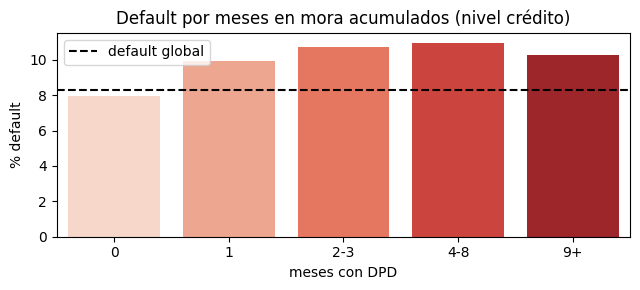

In [26]:
# percentiles y criterio de severo (Máx > 3xp99) sobre los ejes derivados de la sección 6
derivados = ["meses_obs", "n_rep", "n_dpd", "pct_dpd", "worst"]
perc = credf[derivados].describe(percentiles=[.5, .9, .95, .99]).T[["50%", "90%", "95%", "99%", "max"]]
perc["Máx/p99"] = (perc["max"] / perc["99%"]).round(2)
perc["severo"] = np.where(perc["max"] > 3 * perc["99%"], "sí", "no")
display(perc.round(2))

# la cola se compara contra el resto de créditos con mora, no contra los limpios 
sev = credf["n_dpd"] > credf["n_dpd"].quantile(.99)
ev_cred.evaluar_flags([("n_dpd > p99", sev, con_dpd, "créditos con mora")])

binsn = pd.cut(credf["n_dpd"], [-1, 0, 1, 3, 8, 100], labels=["0", "1", "2-3", "4-8", "9+"])
tabn = credf.groupby(binsn, observed=True)["TARGET"].agg(n="size", tasa="mean")
tabn["tasa"] = (tabn["tasa"] * 100).round(2)
display(tabn)

fig, ax = plt.subplots(figsize=(6.5, 3))
etiquetas = tabn.index.astype(str)
sns.barplot(x=etiquetas, y=tabn["tasa"], hue=etiquetas, palette="Reds", legend=False, ax=ax)
ax.axhline(credf["TARGET"].mean() * 100, color="black", ls="--", label="default global")
ax.set(title="Default por meses en mora acumulados (nivel crédito)", xlabel="meses con DPD", ylabel="% default")
ax.legend(); plt.tight_layout(); plt.show()

In [27]:
# cola a nivel cliente: créditos con histórico por cliente
n_cred_cli = map_bc.groupby("SK_ID_CURR").size()
p99_cli = n_cred_cli.quantile(.99)
print(f"créditos con histórico por cliente: mediana {n_cred_cli.median():.0f}, p99 {p99_cli:.0f}, "
      f"máx {n_cred_cli.max()} (Máx/p99 = {n_cred_cli.max() / p99_cli:.2f})")
binsc = pd.cut(n_cred_cli, [0, 2, 5, 10, 21, 200], labels=["1-2", "3-5", "6-10", "11-21", "22+"])
tabc = tgt_cli.reindex(n_cred_cli.index).groupby(binsc, observed=True).agg(n="size", tasa="mean")
tabc["tasa"] = (tabc["tasa"] * 100).round(2)
display(tabc)

credf["activo"] = bureau.set_index("SK_ID_BUREAU")["CREDIT_ACTIVE"].reindex(credf.index).astype(str)
cens_dpd = credf["censurado"] & credf["rec_dpd"].ge(credf["fin"] - 3)  # DPD en los últimos 3 meses de su ventana
grupos = {"censurado con DPD al final": cens_dpd,
          "censurado sin DPD al final": credf["censurado"] & ~cens_dpd,
          "llega al mes 0": ~credf["censurado"]}

filas = []
for k, m in grupos.items():
    vc = credf.loc[m, "activo"].value_counts(normalize=True).mul(100)
    filas.append({"grupo": k, "n": int(m.sum()), "% default": round(credf.loc[m, "TARGET"].mean() * 100, 2),
                  "% Sold + Bad debt": round(vc.get("Sold", 0) + vc.get("Bad debt", 0), 2),
                  "% Closed": round(vc.get("Closed", 0), 2), "% Active": round(vc.get("Active", 0), 2)})
display(pd.DataFrame(filas))

créditos con histórico por cliente: mediana 5, p99 21, máx 116 (Máx/p99 = 5.52)


,n,tasa
1-2,24400,8.70
3-5,30079,7.60
6-10,25933,7.90
11-21,11070,8.74
22+,749,11.08


,grupo,n,% default,% Sold + Bad debt,% Closed,% Active
0,censurado con DPD al final,5755,14.42,0.52,70.13,29.35
1,censurado sin DPD al final,172090,8.05,0.46,77.76,21.78
2,llega al mes 0,345670,8.28,0.36,55.03,44.61


El histórico mensual del buró no tiene ninguna variable financiera: los estados son ocho códigos discretos y el eje temporal vive en un rango cerrado de -96 a 0, los dos acotados por construcción. Eso descarta de entrada el problema habitual de los importes (colas de millones que pueden ser error de captura) y desplaza el riesgo de dato a otros tres sitios: el denominador de los ratios de mora, lo que se pierde al enlazar con `bureau`, y la cola de las variables que yo mismo derivo del histórico.

En validez de dominio no hay nada que revertir: 0 valores del eje temporal fuera de rango y 0 códigos de estado fuera del dominio. Es lo contrario de lo que encontré en `bureau`, donde hay importes de 396M y fechas de cierre de hace 115 años que habrá que anular o capar aunque tengan señal. Aquí el criterio de validez de dominio no retira ni una observación.

El control lógico que sí me importaba es si el cierre es absorbente, porque el análisis de trayectoria parte de que un crédito cerrado no vuelve a reportar. De los 278.937 créditos con algún mes en `C`, solo 5 tienen un estado distinto posterior a su primer cierre, y son 6 filas en total (cinco en `1` y una en `2`). Con esa magnitud lo trato como ruido de reporte y doy la trayectoria por bien construida.

El segundo control es de coherencia con `bureau`, y consiste en comprobar que la ventana mensual encaja con la fecha de apertura del crédito. El desfase entre los meses observados y los transcurridos desde `DAYS_CREDIT` tiene mediana de 0,5 meses y p95 de 1,0, o sea que el histórico arranca justo en la apertura. Hay 16.014 créditos (3,06%) cuya ventana parece empezar antes de que el crédito exista, pero el exceso máximo es de 1,1 meses y no discriminan (8,30% frente a 8,27%, p=0,90): es el redondeo de 30,44 días por mes, no una inconsistencia de dato.

La calidad del enlace sí deja un hallazgo, y cierra el pendiente que dejé abierto al medir la cobertura. Esperaba que los créditos huérfanos, los que aparecen en el histórico mensual pero no en `bureau`, fuesen una pérdida neutra, y no lo son: esos 43.041 créditos suman 3.120.184 filas, el 11,43% de la tabla, y tienen otro perfil. Su mediana es de 97 meses de histórico frente a 25 de los enlazables, con 67,03% de meses cerrados frente a 47,79% y 0,93% de meses en mora frente a 1,30%. Lo que el cruce descarta es historia antigua, cerrada y limpia. La pérdida no es aleatoria, pero va en una dirección conocida y benigna para lo que me interesa, porque no infla artificialmente la mora de la muestra que sí puedo analizar. No puedo medir su default, porque sin `bureau` no hay cliente al que atribuirlo, así que lo dejo documentado como sesgo de cobertura y no como algo a corregir.

El bloque con más consecuencias para la agregación es el del denominador. Ya había concluido que el estado `X` es ausencia de dato y que `C` está fuera de la escala de mora, y aquí veo cuántos créditos se quedan sin ningún estado numérico por esa vía: 67.116 (12,82%), de los cuales 47.488 no tienen más que `X` en toda su ventana. Su default es 8,80% frente a 8,20% (+0,61pp, z=5,3, p=1,04e-07), otra vez significancia por volumen con un efecto muy por debajo del umbral práctico de 2pp. La consecuencia no es que haya que crear una feature con ellos, es que no se pueden confundir con créditos sin mora: al agregar, su severidad y su intensidad tienen que quedar en `NaN`, nunca en 0, porque fusionar "sin dato" con "sin mora" es exactamente la codificación que diluye la señal rara.

El mismo problema de denominador ataca al ratio de intensidad por el otro extremo. Los 729 créditos que pasaron el 100% de sus meses reportados en mora no son los más morosos del histórico, son los que tienen el denominador más pequeño: 280 de ellos alcanzan ese 100% con un único mes reportado. Y no discriminan, porque dan 10,01% frente al 10,34% del resto de créditos con mora (p=0,77). Con 93.033 créditos (17,77%) por debajo de dos meses reportados, la lectura es que el porcentaje de meses en mora necesita un denominador mínimo para ser interpretable, o directamente cede el sitio al conteo y a la recencia.

Con eso controlado, la cola de las variables derivadas sale corta. Aplicando el criterio de severo (Máx > 3xp99), los meses observados (1,07), los meses reportados (2,04), el porcentaje de meses en mora (1,57) y el peor estado alcanzado (1,67) no lo cumplen, porque los cuatro están acotados por la ventana o por la escala. El único severo es el número de meses en mora, con un máximo de 89 frente a un p99 de 8, un ratio de 11,12. Esperaba que ese extremo fuese el moroso crónico y que rindiese como tal, y no es así: medido contra el resto de créditos con mora, y no contra los limpios, para no mezclarlo con el efecto de tener mora, la cola da 10,27% frente a 10,34% (p=0,87). El gradiente completo lo explica mejor que el test: 7,97% sin ningún mes en mora, 9,94% con uno, 10,69% con dos o tres, 10,97% con cuatro a ocho y 10,27% con nueve o más. La señal salta en el primer mes de mora y luego satura, incluso cae en el último tramo. Acumular meses no añade nada sobre haberla tenido, que es la misma conclusión que ya daban la comparación entre la escala ordinal y la binaria, y el hecho de que la recencia gane a la severidad.

A nivel cliente sí queda una cola con señal. El número de créditos con histórico por cliente tiene mediana 5, p99 de 21 y un máximo de 116, un ratio de 5,52 sobre el p99 y exactamente el mismo tope que el conteo de créditos de `bureau`, así que probablemente es el mismo cliente. El patrón por tramos es la misma U que ya vi allí (8,70% con uno o dos créditos, 7,60% con tres a cinco, 7,90% con seis a diez, 8,74% con once a veintiuno) y la cola se despega: 11,08% en los 749 clientes con 22 créditos o más. No es error de captura y no lo capo. Lo que sí hace es matizar el descarte del conteo de créditos con histórico: la variable continua es ruido, pero su extremo marca riesgo, así que si entra lo hará como flag de cola y no como conteo.

Al controlar la ventana de observación vi que un crédito que entra en mora justo antes de dejar de reportarse llega al 23,60% de default, y lo interpreté como cierre problemático, apuntando a venta o traspaso a recobro y por tanto a las categorías 'Sold' y 'Bad debt' de `bureau`. Lo dejé marcado como indicativo y aquí lo verifico cruzando con el estado del crédito, y el mecanismo concreto **queda refutado**: los 5.755 créditos censurados con mora en los últimos tres meses de su ventana tienen un 0,52% de 'Sold' más 'Bad debt', prácticamente lo mismo que los censurados sin mora al final (0,46%) y que los que llegan al mes de la solicitud (0,36%). Lo que sí cambia, y mucho, es el cierre ordinario: 70,13% de 'Closed' frente al 55,03% de los que llegan al mes de la solicitud. Así que la mitad de la lectura se sostiene, porque dejar de reportar tras la mora es un cierre y el riesgo es real (14,42% de default frente al 8,05% de los censurados sin mora al final), y la otra mitad no, porque el buró no los etiqueta como venta ni como recobro. Es una diferencia de reporte, no de gravedad, y la corrijo para no arrastrar una explicación causal que los datos no sostienen.

Cierro con el aviso metodológico que condiciona todo el análisis a nivel de crédito y de mes. Los 14.701.612 crédito-mes con TARGET no son observaciones independientes: cuelgan de 92.231 clientes que comparten su etiqueta, y un crédito con ventana larga aporta decenas de filas con el mismo valor. Eso hace anticonservadores sus p-valores, que es por lo que aquí decido por tamaño del efecto y no por significancia, y por lo que toda cifra medida sobre el histórico mensual es orientativa hasta que se revalide a nivel cliente.

Lo que queda para la agregación:

- El dato crudo está limpio y las colas que existen son reales.
- Los créditos sin ningún estado numérico van a `NaN` en severidad e intensidad, nunca a 0.
- La intensidad normalizada necesita denominador mínimo, o cede el sitio al conteo y a la recencia, que es lo que la evidencia venía pidiendo.
- El sesgo de cobertura de los huérfanos queda documentado: lo que se pierde al enlazar es historia antigua, cerrada y con menos mora.